Suppose we are running an online business that sells groceries.  We want to create a table that represents the characteristics of the groceries.  Each item has a name; a price; a quantity purchased; a date of purchase; and a state in which it was purchased.

I am going to deliberately introduce null values, duplicate rows, and data values that don't make sense.  I will then pretend I don't know about these problems and write some code to detect them.

# Constructing Dataset (This wouldn't happen for real data, but can be used to test your ideas)

In [235]:
import random
import pandas as pd
from datetime import datetime
from datetime import timedelta
import numpy as np

np.random.seed(0)
random.seed(0)

In [244]:
numrows = 100
grocery_names = ["apples_pound", "oranges_pound", "bananas_pound", "milk_gallon", "lettuce"]
df_groceries = pd.DataFrame({})
df_groceries["name"] = [random.choice(["apples_pound", "oranges_pound", "bananas_pound", "milk_gallon", "lettuce"]) for num in range(numrows)]
#np.random.choice(grocery_names, numrows)

In [245]:
def choose_unit_price(name):
    retval = None
    if(name == "apples_pound"):
        retval = random.uniform(1.00, 2.00)
    elif(name == "oranges_pound"):
        retval = random.uniform(2.00, 4.00)
    elif(name == "bananas_pound"):
        retval = random.uniform(1.00, 2.00)
    elif(name == "milk_gallon"):
        retval = random.uniform(3.00, 5.00)
    elif(name == "lettuce"):
        retval = random.uniform(1.50, 2.50)
    return np.round(retval, 2)

In [246]:
df_groceries["unit_price"] = df_groceries["name"].apply(choose_unit_price)
df_groceries["quantity"] = [random.randint(1, 5) for num in range(numrows)]

(array([17., 15., 21.,  5.,  3.,  6., 12., 11.,  4.,  6.]),
 array([1.03 , 1.387, 1.744, 2.101, 2.458, 2.815, 3.172, 3.529, 3.886,
        4.243, 4.6  ]),
 <BarContainer object of 10 artists>)

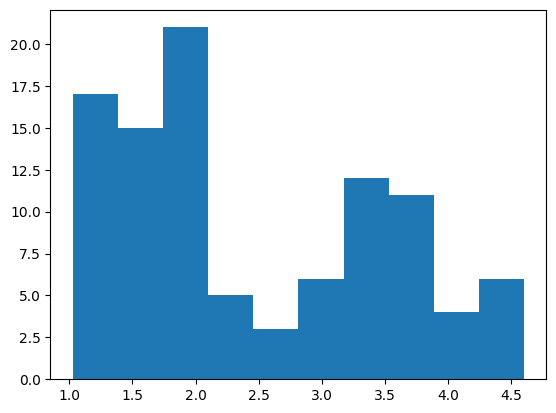

In [247]:
plt.hist(df_groceries.unit_price)

In [248]:
df_groceries

,name,unit_price,quantity
0,lettuce,1.75,3
1,bananas_pound,1.32,2
2,apples_pound,1.25,2
3,bananas_pound,1.28,4
4,oranges_pound,3.22,2
...,...,...,...
95,lettuce,1.57,4
96,milk_gallon,3.27,1
97,milk_gallon,3.64,3
98,milk_gallon,3.58,2


In [249]:
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size = numrows)
df_groceries["date_purchased"] = start + pd.to_timedelta(random_days, unit='D')
df_groceries["state"] = [random.choice(["NY", "MA", "CA"]) for num in range(numrows)]

In [250]:
df_groceries

,name,unit_price,quantity,date_purchased,state
0,lettuce,1.75,3,2024-07-11,MA
1,bananas_pound,1.32,2,2022-04-15,NY
2,apples_pound,1.25,2,2022-02-02,NY
3,bananas_pound,1.28,4,2024-09-27,NY
4,oranges_pound,3.22,2,2022-10-30,CA
...,...,...,...,...,...
95,lettuce,1.57,4,2020-11-03,MA
96,milk_gallon,3.27,1,2023-01-09,NY
97,milk_gallon,3.64,3,2025-09-11,NY
98,milk_gallon,3.58,2,2023-04-21,NY


In [175]:
df_groceries.shape, numdays / 100

((100, 5), 21.92)

# Begin Data Cleaning and EDA

In [251]:
df_groceries

,name,unit_price,quantity,date_purchased,state
0,lettuce,1.75,3,2024-07-11,MA
1,bananas_pound,1.32,2,2022-04-15,NY
2,apples_pound,1.25,2,2022-02-02,NY
3,bananas_pound,1.28,4,2024-09-27,NY
4,oranges_pound,3.22,2,2022-10-30,CA
...,...,...,...,...,...
95,lettuce,1.57,4,2020-11-03,MA
96,milk_gallon,3.27,1,2023-01-09,NY
97,milk_gallon,3.64,3,2025-09-11,NY
98,milk_gallon,3.58,2,2023-04-21,NY


In [177]:
#df_groceries.groupby("name").unit_price.agg(["mean", "max", "min", "std"])

In [252]:
df_groceries.describe()

,unit_price,quantity,date_purchased
count,100.00000,100.000000,100
mean,2.43690,2.720000,2023-04-27 01:55:12
min,1.03000,1.000000,2020-03-25 00:00:00
25%,1.55000,2.000000,2021-10-16 00:00:00
50%,2.05000,3.000000,2023-03-31 12:00:00
75%,3.39000,4.000000,2025-03-23 18:00:00
max,4.60000,5.000000,2025-12-16 00:00:00
std,1.02889,1.295525,NaN


In [253]:
df_groceries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   name            100 non-null    object        
 1   unit_price      100 non-null    float64       
 2   quantity        100 non-null    int64         
 3   date_purchased  100 non-null    datetime64[ns]
 4   state           100 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 4.0+ KB


In [254]:
df_groceries.shape

(100, 5)

In [255]:
# Introducing "bugs"
df_groceries.loc[4, "state"] = np.nan # missing number / nan
df_groceries.loc[1, "unit_price"] = 1000000 # outlier / anomaly
df_groceries.loc[3, "state"] = "ZZ" # invalid
df_groceries.loc[2, "name"] = "television" # invalid

In [256]:
df_groceries

,name,unit_price,quantity,date_purchased,state
0,lettuce,1.75,3,2024-07-11,MA
1,bananas_pound,1000000.00,2,2022-04-15,NY
2,television,1.25,2,2022-02-02,NY
3,bananas_pound,1.28,4,2024-09-27,ZZ
4,oranges_pound,3.22,2,2022-10-30,NaN
...,...,...,...,...,...
95,lettuce,1.57,4,2020-11-03,MA
96,milk_gallon,3.27,1,2023-01-09,NY
97,milk_gallon,3.64,3,2025-09-11,NY
98,milk_gallon,3.58,2,2023-04-21,NY


In [183]:
#np.where(df_groceries.isna().sum(axis = 0) == 1)

In [261]:
# Detecting "bugs"
df_groceries.isna().sum(axis = 0)

name              0
unit_price        0
quantity          0
date_purchased    0
state             1
dtype: int64

In [263]:
arr = np.zeros(100, dtype = bool)
arr[4] = True
arr[3] = True
df_groceries[arr]

,name,unit_price,quantity,date_purchased,state
3,bananas_pound,1.28,4,2024-09-27,ZZ
4,oranges_pound,3.22,2,2022-10-30,NaN


In [186]:
for x in df_groceries.columns:
    print(x, df_groceries[df_groceries[x].isna()])

name Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
unit_price Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
quantity Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
date_purchased Empty DataFrame
Columns: [name, unit_price, quantity, date_purchased, state]
Index: []
state           name  unit_price  quantity date_purchased state
4  milk_gallon        3.23         4     2020-05-23   NaN


In [187]:
df_groceries.loc[10, "unit_price"] = "bad_value"
#df_groceries['unit_price'][0:12]
pd.to_numeric(df_groceries['unit_price'], errors='coerce')[0:12]

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_46162/2770674302.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'bad_value' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_groceries.loc[10, "unit_price"] = "bad_value"


0           1.32
1     1000000.00
2           3.76
3           4.43
4           3.23
5           1.24
6           1.82
7           1.54
8           1.81
9           3.60
10           NaN
11          1.99
Name: unit_price, dtype: float64

In [188]:
np.where(pd.to_numeric(df_groceries['unit_price'], errors='coerce').notnull() == 0)

(array([10]),)

In [189]:
df_groceries.loc[10, "unit_price"] = "bad_value"
df_g2 = df_groceries[pd.to_numeric(df_groceries['unit_price'], errors='coerce').notnull()]
df_g2.iloc[0:11]

,name,unit_price,quantity,date_purchased,state
0,bananas_pound,1.32,2,2025-11-26,NY
1,apples_pound,1000000.0,4,2025-02-07,NY
2,television,3.76,5,2025-08-12,MA
3,milk_gallon,4.43,4,2022-02-24,ZZ
4,milk_gallon,3.23,4,2020-05-23,NaN
5,bananas_pound,1.24,5,2021-12-08,MA
6,bananas_pound,1.82,4,2023-09-27,NY
7,bananas_pound,1.54,4,2024-02-29,NY
8,lettuce,1.81,4,2022-01-24,MA
9,oranges_pound,3.6,1,2025-03-08,CA


In [190]:
df_g2.groupby("state").unit_price.mean()

state
CA        2.329375
MA        2.472759
NY    27779.659444
ZZ            4.43
Name: unit_price, dtype: object

In [191]:
df_groceries.groupby("state").size()

state
CA    32
MA    30
NY    36
ZZ     1
dtype: int64

In [192]:
df_g2.groupby("state").agg({"unit_price": "max", "quantity": "max", "date_purchased": "max"})

,unit_price,quantity,date_purchased
state,,,
CA,4.65,5,2025-12-10
MA,4.99,5,2025-11-06
NY,1000000.0,5,2025-12-08
ZZ,4.43,4,2022-02-24


In [193]:
df_groceries[df_groceries["state"] != "ZZ"].groupby("state").size()

state
CA    32
MA    30
NY    36
dtype: int64

In [194]:
unit_price = np.array([x for x in df_groceries["unit_price"] if not isinstance(x, str)])

In [195]:
np.histogram(unit_price, bins = 3)

(array([98,  0,  1]),
 array([1.00000e+00, 3.33334e+05, 6.66667e+05, 1.00000e+06]))

In [196]:
unit_price_fixed = unit_price[unit_price < 10]

In [197]:
np.histogram(unit_price_fixed)

(array([28, 21, 15,  2,  3,  5, 12,  4,  6,  2]),
 array([1.   , 1.399, 1.798, 2.197, 2.596, 2.995, 3.394, 3.793, 4.192,
        4.591, 4.99 ]))

# Graph presentation

(array([28., 21., 15.,  2.,  3.,  5., 12.,  4.,  6.,  2.]),
 array([1.   , 1.399, 1.798, 2.197, 2.596, 2.995, 3.394, 3.793, 4.192,
        4.591, 4.99 ]),
 <BarContainer object of 10 artists>)

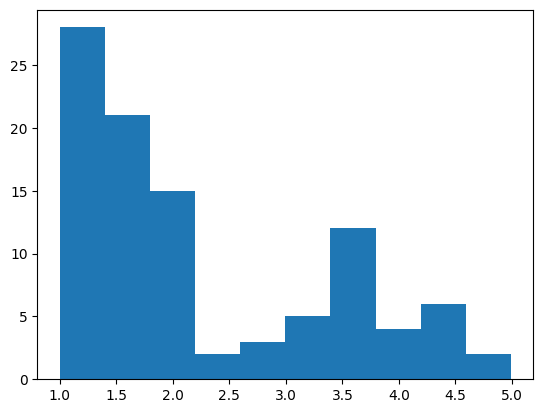

In [198]:
import matplotlib.pyplot as plt
plt.hist(unit_price_fixed)

(array([49., 17.,  8., 16.,  8.]),
 array([1.   , 1.798, 2.596, 3.394, 4.192, 4.99 ]),
 <BarContainer object of 5 artists>)

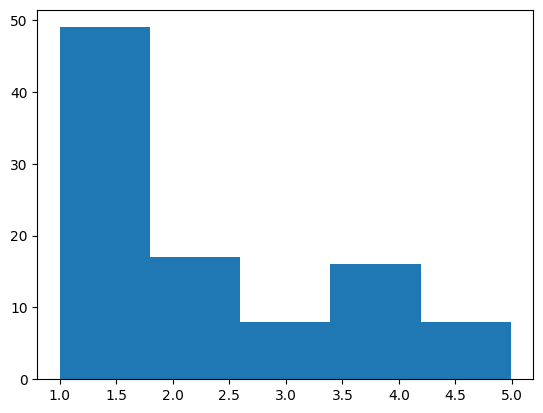

In [199]:
plt.hist(unit_price_fixed, bins = 5)

(array([14., 14., 12.,  9., 12.,  3.,  0.,  2.,  3.,  0.,  2.,  3.,  2.,
        10.,  3.,  1.,  1.,  5.,  1.,  1.]),
 array([1.    , 1.1995, 1.399 , 1.5985, 1.798 , 1.9975, 2.197 , 2.3965,
        2.596 , 2.7955, 2.995 , 3.1945, 3.394 , 3.5935, 3.793 , 3.9925,
        4.192 , 4.3915, 4.591 , 4.7905, 4.99  ]),
 <BarContainer object of 20 artists>)

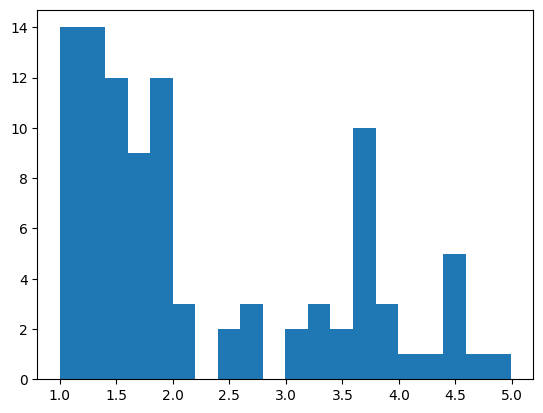

In [200]:
plt.hist(unit_price_fixed, bins = 20)

(array([0.7160759 , 0.7160759 , 0.61377935, 0.46033451, 0.61377935,
        0.15344484, 0.        , 0.10229656, 0.15344484, 0.        ,
        0.10229656, 0.15344484, 0.10229656, 0.51148279, 0.15344484,
        0.05114828, 0.05114828, 0.25574139, 0.05114828, 0.05114828]),
 array([1.    , 1.1995, 1.399 , 1.5985, 1.798 , 1.9975, 2.197 , 2.3965,
        2.596 , 2.7955, 2.995 , 3.1945, 3.394 , 3.5935, 3.793 , 3.9925,
        4.192 , 4.3915, 4.591 , 4.7905, 4.99  ]),
 <BarContainer object of 20 artists>)

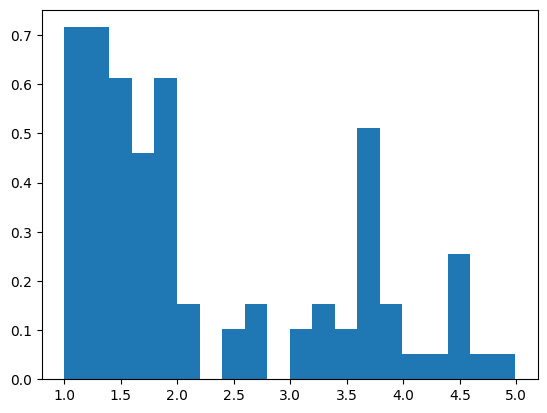

In [201]:
plt.hist(unit_price_fixed, bins = 20, density = True)

(array([0.14285714, 0.28571429, 0.40816327, 0.5       , 0.62244898,
        0.65306122, 0.65306122, 0.67346939, 0.70408163, 0.70408163,
        0.7244898 , 0.75510204, 0.7755102 , 0.87755102, 0.90816327,
        0.91836735, 0.92857143, 0.97959184, 0.98979592, 1.        ]),
 array([1.    , 1.1995, 1.399 , 1.5985, 1.798 , 1.9975, 2.197 , 2.3965,
        2.596 , 2.7955, 2.995 , 3.1945, 3.394 , 3.5935, 3.793 , 3.9925,
        4.192 , 4.3915, 4.591 , 4.7905, 4.99  ]),
 <BarContainer object of 20 artists>)

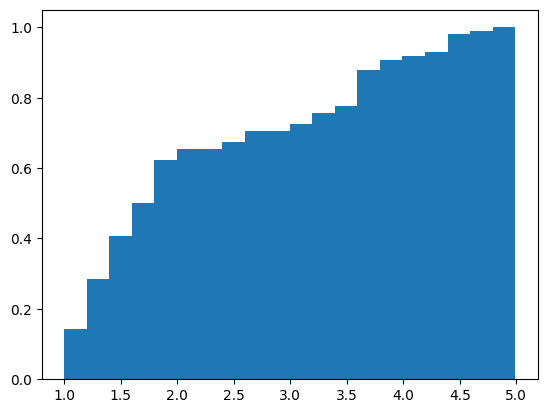

In [203]:
plt.hist(unit_price_fixed, bins = 20, density = True, cumulative = True)

In [205]:
np.sort(unit_price)[-5:]

array([4.57e+00, 4.58e+00, 4.65e+00, 4.99e+00, 1.00e+06])

In [206]:
np.sort(unit_price)[np.sort(unit_price) < 5][-5:]

array([4.53, 4.57, 4.58, 4.65, 4.99])

In [32]:
df_groceries.groupby("name").size()

name
apples_pound     27
bananas_pound    19
lettuce          20
milk_gallon      15
oranges_pound    18
television        1
dtype: int64

In [207]:
df_type = df_groceries.map(type)
for col in df_type.columns:
    print(col, df_type[col].unique())

name [<class 'str'>]
unit_price [<class 'float'> <class 'str'>]
quantity [<class 'int'>]
date_purchased [<class 'pandas._libs.tslibs.timestamps.Timestamp'>]
state [<class 'str'> <class 'float'>]


In [209]:
np.where([isinstance(x, str) for x in df_groceries.unit_price])

(array([10]),)

In [210]:
np.where([isinstance(x, float) for x in df_groceries.state])

(array([4]),)

In [264]:
df_groceries_fixed = df_groceries[np.vectorize(lambda x: isinstance(x, float) and  x < 10)(df_groceries["unit_price"])]

In [265]:
df_groceries_fixed[["unit_price", "quantity", "date_purchased"]].mean(axis = 0)

unit_price                   2.448182
quantity                     2.727273
date_purchased    2023-04-30 21:20:00
dtype: object